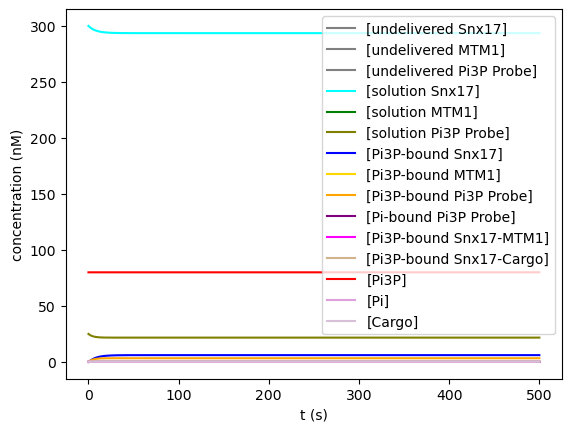

Final Equilibriated Trajectories:
[undelivered Snx17] 0.0
[undelivered MTM1] 0.0
[undelivered Pi3P Probe] 0.0
[solution Snx17] 293.55696505528493
[solution MTM1] 0.0
[solution Pi3P Probe] 21.70583415018401
[Pi3P-bound Snx17] 6.059978660000651
[Pi3P-bound MTM1] 0.0
[Pi3P-bound Pi3P Probe] 3.294165849814977
[Pi-bound Pi3P Probe] 0.0
[Pi3P-bound Snx17-MTM1] 0.0
[Pi3P-bound Snx17-Cargo] 0.3830562847302908
[Pi3P] 80.0
[Pi] 0.0
[Cargo] 0.4


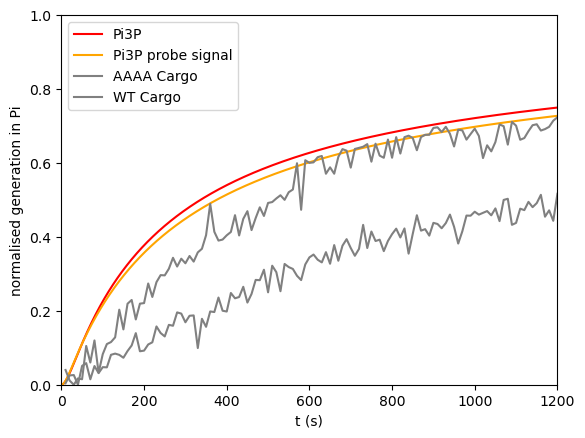

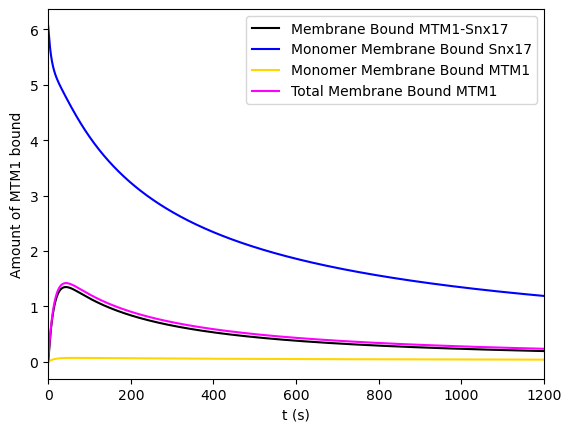

In [51]:
import sys
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import csv

# ============================= Key =============================

# S = Snx17
# M = MTM1
# P = ProbeN
# A = Pi3P
# B = Pi
# C = Cargo

# ========================= User Inputs =========================

input_data_file_name = "cargo_for_plot.csv"

affinities = {
    "Kd_SA": 3160, #nM Snx17 to Pi3P
    "Kd_MA": 13531, #228, #20000, #7000, #nM MTM1 to Pi3P
    "Kd_PA": 457, #nM Probe to Pi3P
    "Kd_PB": 45700, #nM Probe to Pi
    "Kd_SM": 150,#150, #molecules/um2 Snx17 to MTM1 ; KD2D = h * KD3D (in um3); 150 = 25uM
    "Kd_SC": 150,#150, #molecules/um2 Snx17 to Cargo; 150 = 25uM
}

Volume = 20E+9 #um3 (uL * 1E+9)
TotalMembraneSA = 19100883 #um2

#equilibriation simulation <- this is the beeds before adition of MTM1
eq_Snx17_conc = 300 #nM
eq_MTM1_conc = 0 #50 #nM
eq_Probe_conc = 25 #250 #nM
eq_cargo_conc = 0.00025 #0.1 # 0.10 # e.g. 0.01 = 1% Pi3P membranes
PC_concentration = 1600 #nM
membrane_substrate = 0.05 # e.g. 0.05 = 5% Pi3P membranes
membrane_product = 0 # e.g. 0 = 0% Pi membranes
equilibration_time = [0, 500] # t_0 (s) and t_final (s)

#assay simulation <- this is the adition of MTM1 at the microscope
initial_Snx17_conc = 0 #nM
initial_MTM1_conc = 50 #50 #12.5 #nM
initial_Probe_conc = 0 #250 #nM
simulation_time = [0, 1200] # t_0 (s) and t_final (s)

diffusion_effect = 0.1 #nM s-1 <- The rate of difusion from the site of assay buffer adition to the beed compartment

# ========================= Import Data =========================

df = pd.read_csv(input_data_file_name) #("OptionC_time_50M_25M_50MS_25MS.csv") #("0nMNaCl_tirtration_200_100_50_25_12-5.csv")
df_time_min = df["time (min)"].tolist()
df_time = []
for t in df_time_min:
    df_time.append(t*60)
df_50M = df["WT"].tolist() #df["50nM MTM1"].tolist() #df["50nM MTM1"].tolist()
df_25M = df["AAAA"].tolist() #df["25nM MTM1"].tolist() #df["25nM MTM1"].tolist()
#df_50MS = df["50nM MTM1 + 300nM Snx17"].tolist() #df["50nM MTM1 + 300nM Snx17"].tolist()
#df_25MS = df["25nM MTM1 + 300nM Snx17"].tolist() #df["25nM MTM1 + 300nM Snx17"].tolist()


# ===================== Rate Fits =====================

kcat_M = 0.0024482#0.00325#0.00245 # s-1 Effective catalytic rate of MTM1
kcat_SM = 0.0024482#0.00325#0.00245 # s-1 Effective catalytic rate of MTM1/Snx17 dimer

# ===================== initialisation =====================

params = {
    "kon_SA": 0.000034, #IMPORTANT
    "koff_SA": (0.093 * (affinities["Kd_SA"]/2700)), #IMPORTANT
    "kon_MA": 0.000034, #IMPORTANT
    "koff_MA": (0.093 * (affinities["Kd_MA"]/2700)), #IMPORTANT
    "kon_PA": 0.00034, #IMPORTANT
    "koff_PA": (0.93 * (affinities["Kd_PA"]/2700)), #IMPORTANT
    "kon_PB": 0.000034,
    "koff_PB": (0.093 * (affinities["Kd_PB"]/2700)), #IMPORTANT
    "kon_SM": 0.00574, #IMPORTANT ; um2 molecule -1 s-1
    "koff_SM": (0.861 * (affinities["Kd_SM"]/150)), #IMPORTANT
    "kon_SC": 0.00574, #IMPORTANT ; um2 molecule -1 s-1
    "koff_SC": (0.861 * (affinities["Kd_SC"]/150)), #IMPORTANT
    "kcat_M": kcat_M, #IMPORTANT
    "kcat_SM": kcat_SM, #IMPORTANT
    "ka": diffusion_effect #0.01 #0.003
}

params["koff_SAM"] = params["koff_SA"] * params["koff_MA"]
params["koff_SAC"] = params["koff_SA"]# * params["koff_SC"]

equilibration_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    eq_Snx17_conc, # Sf
    eq_MTM1_conc, # Mf
    eq_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc # C
]

# ===================== ODE Model =====================

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    
    return kon * substrate * free_form - koff * bound_form

#trajectory_arrays = []
def model(t, y):
    global params
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, A, B, C = y

    kon_SA   = params["kon_SA"]
    koff_SA  = params["koff_SA"]
    kon_MA   = params["kon_MA"]
    koff_MA  = params["koff_MA"]
    kon_PA   = params["kon_PA"]
    koff_PA  = params["koff_PA"]
    kon_PB   = params["kon_PB"]
    koff_PB  = params["koff_PB"]
    kon_SM   = params["kon_SM"]
    koff_SM  = params["koff_SM"]
    koff_SAM = params["koff_SAM"]
    kon_SC   = params["kon_SC"]
    koff_SC  = params["koff_SC"]
    koff_SAC = params["koff_SAC"]
    kcat_M   = params["kcat_M"]
    kcat_SM  = params["kcat_SM"]
    ka       = params["ka"]

    # =================================== ODE equations
    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb*2) - SbC), 0.0) # ensures that [Pi3P] can never fall below 0nM
    B_bind = max((B - PbB), 0.0) # ensures that [Pi] can never fall below 0nM
    C_bind = max((C - SbC), 0.0) # ensures that [Cargo] can never fall below 0nM

    
    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 ([nM] * 0.602 = molecules per um3)
    aSbA = ((SbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 
    aSMb = ((SMb * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aC_bind = ((C_bind * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aSbC = ((SbC * 0.602) * Volume) / TotalMembraneSA # molecules/um2

    # 2D reaction rates (molecules/um2/s)
    # S·A + M·A <-> SM (both membrane-bound)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    
    # S·A + C <-> S·A·C  (S must already be membrane-bound via A)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)
    
    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    SbC_rate_nM = (SbC_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)

    
    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    
    # Calculating state changes in compartment 2
    # Free S, M, and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)
    
    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma)
    
    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    
    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          -SMb_rate_nM + \
          -SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          -SMb_rate_nM
    
    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    
    # SAM complex
    dSMb = SMb_rate_nM -(koff_SAM * SMb)

    # SAC complex
    dSbC = SbC_rate_nM -(koff_SAC * SbC)

    # Catalysis: Pi3P -> Pi
    dB = (kcat_M * MbA * A_bind) + (kcat_SM * SMb * A_bind)
    dA = -dB

    #trajectory_arrays.append([dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dA, dB])
    
    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dA, dB, 0]

# ================= equilibriation Run =================

# Pre-equilibriation
sol = solve_ivp(fun = model,
               t_span = equilibration_time,
               y0 = equilibration_concentrations,
               max_step = 0.01)
y_final = sol.y[:, -1]

#========================= EQ plot

label_list = ["[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]", "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]", "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]",
              "[Pi3P-bound Pi3P Probe]", "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]", "[Pi3P-bound Snx17-Cargo]", "[Pi3P]", "[Pi]", "[Cargo]"]
colour_list = ["grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
              "orange", "purple", "fuchsia", "tan", "red", "plum", "thistle"]

plt.figure()
for i in range(sol.y.shape[0]):
    plt.plot(sol.t, sol.y[i], label=label_list[i], c=colour_list[i])
plt.xlabel('t (s)') # the horizontal axis represents the time
plt.ylabel('concentration (nM)') # the vertical axis represents the concentration
plt.legend() # show how the colors correspond to the components of X
plt.show()


print("Final Equilibriated Trajectories:")
for component_no in enumerate(sol.y[:, -1]):
    print(label_list[component_no[0]], (max((sol.y[:, -1][component_no[0]]), 0.0)))

# ===================== Assay Run =====================

assay_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    initial_Snx17_conc, # Sf
    initial_MTM1_conc, # Mf
    initial_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc, # C
]

for component_no in enumerate(y_final):
    if component_no[1] > 0.0:
        assay_concentrations[component_no[0]] = component_no[1]


# assay simulation
sol = solve_ivp(fun = model,
               t_span = simulation_time,
               y0 = assay_concentrations,
               max_step = 0.01)

#========================= Assay plot

##plt.figure()
##for i in range(sol.y.shape[0]):
##    plt.plot(sol.t, sol.y[i], label=label_list[i], c=colour_list[i])
##plt.xlabel('t (s)') # the horizontal axis represents the time
##plt.ylabel('concentration (nM)') # the vertical axis represents the concentration
##plt.legend() # show how the colors correspond to the components of X
##plt.show()


#========================= Normalised Pi3P plot

normalised_A = []
max_A = max(sol.y[12])
for n in sol.y[12]:
    normalised_A.append(1-(n/max_A))
#print("Final Normalised Pi3P", normalised_A[-1])

normalised_PbA = []
max_PbA = max(sol.y[8])
for n in sol.y[8]:
    normalised_PbA.append(1-(n/max_PbA))
#print("Final Normalised Probe", normalised_PbA[-1])

plt.figure()
plt.plot(sol.t, normalised_A, label="Pi3P", c=colour_list[12])
plt.plot(sol.t, normalised_PbA, label="Pi3P probe signal", c=colour_list[8])

plt.plot(df_time, df_25M, label="AAAA Cargo", c="grey")#"25nM MTM1", c="grey")
plt.plot(df_time, df_50M, label="WT Cargo", c="grey")#"50nM MTM1", c="grey")
#plt.plot(df_time, df_25MS, label="25nM MTM1", c="grey")#"25nM MTM1 + 300nM Snx17", c="grey")
#plt.plot(df_time, df_50MS, label="12.5nM MTM1", c="grey")#"50nM MTM1 + 300nM Snx17", c="grey")

plt.ylim(0, 1)
plt.xlim(0, 1200)
plt.xlabel('t (s)') # the horizontal axis represents the time
plt.ylabel('normalised generation in Pi') # the vertical axis represents the normalised chnage in concentration
plt.legend() # show how the colors correspond to the components of X
plt.show()

#========================= CSV outputs

with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # Header row
    writer.writerow(["time (s)", "Pi3P_norm", "2xPX_norm"])

    # Data rows
    writer.writerows(zip(sol.t, normalised_A, normalised_PbA))

#with open("results_rates.csv", "w", newline="") as f:
#    writer = csv.writer(f)
#    # Header row
#    writer.writerow(["dSa", "dMa", "dPa", "dSf", "dMf", "dPf", "dSbA", "dMbA", "dPbA", "dPbB", "dSMb", "dSbC", "dA", "dB"])
#    # Data rows
#    writer.writerows(trajectory_arrays)

#print("Final Simulated Trajectories:")
#y_final = sol.y[:, -1]
#for component_no in enumerate(sol.y[:, -1]):
#    print(label_list[component_no[0]], (max((sol.y[:, -1][component_no[0]]), 0.0)))



#========================= MTM1 Bound PLot

plot_MB = []
plot_Mb = []
plot_SM = []
plot_SA = []
#plot_Mb = max(sol.y[7])
#plot_SM = max(sol.y[10])

for component_no in enumerate(sol.y[7]):
    plot_MB.append(sol.y[7][component_no[0]] + sol.y[10][component_no[0]])
    plot_Mb.append(sol.y[7][component_no[0]])
    plot_SM.append(sol.y[10][component_no[0]])
    plot_SA.append(sol.y[6][component_no[0]])
    #print("a", sol.y[7])
    #print("b", component_no[0])


#for n in sol.y[7]:
#    plot_Mb.append(n)
#for n in sol.y[10]:
#    plot_SM.append(n)
#combined_MTM1_bound = []
#    for 

plt.figure()
plt.plot(sol.t, plot_SM, label="Membrane Bound MTM1-Snx17", c="black")
plt.plot(sol.t, plot_SA, label="Monomer Membrane Bound Snx17", c=colour_list[6])
plt.plot(sol.t, plot_Mb, label="Monomer Membrane Bound MTM1", c=colour_list[7])
plt.plot(sol.t, plot_MB, label="Total Membrane Bound MTM1", c=colour_list[10])
#plt.ylim(0, 0.42)
plt.xlim(0, 1200)
plt.xlabel('t (s)') # the horizontal axis represents the time
plt.ylabel('Amount of MTM1 bound') # the vertical axis represents the normalised chnage in concentration
plt.legend() # show how the colors correspond to the components of X
plt.show()

#========================= MTM1:Pi3P ratio plot

#Pi3P_MTM1_ratio = []
#for component_no in enumerate(sol.y[12]):
#    if (sol.y[7][component_no[0]] + sol.y[10][component_no[0]]) > 0 and sol.y[12][component_no[0]] > 0:
#       Pi3P_MTM1_ratio.append((sol.y[7][component_no[0]] + sol.y[10][component_no[0]])/(sol.y[12][component_no[0]]))

#plt.figure()
#plt.plot(sol.t[201:], Pi3P_MTM1_ratio[200:], label="MTM1:Pi3P", c="black")
##plt.ylim(0.0006, 0.020)
##plt.xlim(0, 120)
#plt.xlabel('t (s)') # the horizontal axis represents the time
#plt.ylabel('Amount of MTM1 bound') # the vertical axis represents the normalised chnage in concentration
#plt.legend() # show how the colors correspond to the components of X
##plt.show()


#    X0 = Sf
#    X1 = Mf
#    X2 = Pf
#    X3 = SbA
#    X4 = MbA
#    X5 = PbA
#    X6 = PbB
#    X7 = SMb
#    X8 = A
#    X9 = B